# CMS inventory worked example

This short notebook demonstrates the inventory calculation for two synthetic
sources. It is a worked calculation only: it does not run an inversion,
represent ground truth, tune uncertainty parameters, or evaluate coverage.

## 1. Synthetic inputs

The example covers one week of 15-minute intervals. Sources and intervals are
generated independently, and each inferred rate is either exactly zero or a
positive lognormal draw. An independently generated uniform value determines
whether each source-interval is an information interval. Exact-zero estimates
are retained when they occur during information intervals.

The illustrative rule

$$
v_i=0.1^2+(0.5q_i)^2
$$

is arbitrary and is **not** a recommended uncertainty calibration. The
inventory function accepts ready-to-use variance inputs, which may already
include an application-specific discrepancy allowance. Editable parameters
are grouped at the top of the next cell.


In [16]:
import numpy as np
import pandas as pd

# EDITABLE PARAMETERS -------------------------------------------------------
RANDOM_SEED = 1
DAYS = 7
DT_HOURS = 0.25
INFORMATION_FRACTIONS = {"Source 1": 0.70, "Source 2": 0.30}
SOURCE_PARAMETERS = {
    "Source 1": {"positive_probability": 0.40, "positive_median": 1.0, "log_sd": 0.5},
    "Source 2": {"positive_probability": 0.15, "positive_median": 3.0, "log_sd": 1.0},
}
# ---------------------------------------------------------------------------

N_INTERVALS = int(DAYS * 24 / DT_HOURS)
rng = np.random.default_rng(RANDOM_SEED)
source_data = {}

for source, parameters in SOURCE_PARAMETERS.items():
    is_positive = rng.random(N_INTERVALS) < parameters["positive_probability"]
    rates = np.zeros(N_INTERVALS)
    rates[is_positive] = rng.lognormal(
        mean=np.log(parameters["positive_median"]),
        sigma=parameters["log_sd"],
        size=is_positive.sum(),
    )
    variances = 0.1**2 + (0.5 * rates) ** 2
    information_uniform = rng.random(N_INTERVALS)
    information_mask = information_uniform < INFORMATION_FRACTIONS[source]
    source_data[source] = pd.DataFrame(
        {
            "interval": np.arange(N_INTERVALS),
            "rate_kg_per_hr": rates,
            "variance_kg2_per_hr2": variances,
            "information_uniform": information_uniform,
            "is_information": information_mask,
        }
    )

print(f"Intervals per source: {N_INTERVALS} ({DAYS} days at {DT_HOURS:g} hr)")
pd.DataFrame(
    {
        "source": list(source_data),
        "target_information_fraction": [INFORMATION_FRACTIONS[s] for s in source_data],
        "realized_information_fraction": [source_data[s]["is_information"].mean() for s in source_data],
        "information_intervals": [source_data[s]["is_information"].sum() for s in source_data],
    }
).round(3)


Intervals per source: 672 (7 days at 0.25 hr)


,source,target_information_fraction,realized_information_fraction,information_intervals
0,Source 1,0.7,0.714,480
1,Source 2,0.3,0.323,217


The histograms below show the inferred rates that remain after applying each
source's information mask. They therefore include informative exact-zero
estimates but exclude all no-information intervals. Both panels use the same
rate axis.


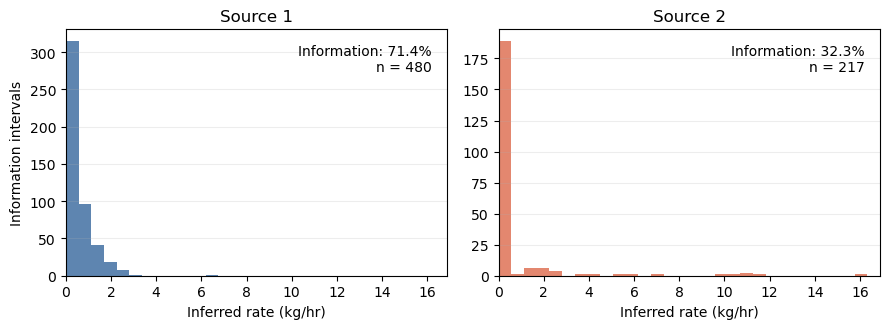

In [17]:
import matplotlib.pyplot as plt

SOURCE_COLORS = {"Source 1": "#4C78A8", "Source 2": "#E07A5F"}


def plot_information_rate_histograms(data):
    information_rates = {
        source: frame.loc[frame["is_information"], "rate_kg_per_hr"].to_numpy()
        for source, frame in data.items()
    }
    common_max = max(rates.max() for rates in information_rates.values())
    common_max *= 1.05
    bins = np.linspace(0.0, common_max, 31)
    fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4), sharex=True)
    for ax, (source, frame) in zip(axes, data.items()):
        rates = information_rates[source]
        information_fraction = frame["is_information"].mean()
        ax.hist(rates, bins=bins, color=SOURCE_COLORS[source], alpha=0.9)
        ax.text(
            0.96,
            0.94,
            f"Information: {information_fraction:.1%}\nn = {len(rates):,}",
            transform=ax.transAxes,
            ha="right",
            va="top",
        )
        ax.set_title(source)
        ax.set_xlabel("Inferred rate (kg/hr)")
        ax.set_xlim(0.0, common_max)
        ax.grid(axis="y", alpha=0.22)
    axes[0].set_ylabel("Information intervals")
    fig.tight_layout()
    plt.show()


def plot_inventory_estimates(table):
    source_names = ["Source 1", "Source 2"]
    x = np.arange(3)
    fig, ax = plt.subplots(figsize=(6.8, 4.3))

    for index, source in enumerate(source_names):
        ax.bar(
            x[index],
            table.loc[source, "estimate_kg"],
            color=SOURCE_COLORS[source],
            width=0.65,
            label=source,
        )

    bottom = 0.0
    for source in source_names:
        contribution = table.loc[source, "estimate_kg"]
        ax.bar(
            x[2],
            contribution,
            bottom=bottom,
            color=SOURCE_COLORS[source],
            width=0.65,
        )
        bottom += contribution

    estimates = table.loc[[*source_names, "Site total"], "estimate_kg"].to_numpy(float)
    lower = table.loc[[*source_names, "Site total"], "ci95_lower_kg"].to_numpy(float)
    upper = table.loc[[*source_names, "Site total"], "ci95_upper_kg"].to_numpy(float)
    ax.errorbar(
        x,
        estimates,
        yerr=np.vstack([estimates - lower, upper - estimates]),
        fmt="none",
        ecolor="#333333",
        elinewidth=1.6,
        capsize=4,
        capthick=1.6,
    )
    ax.set_xticks(x, [*source_names, "Site total"])
    ax.set_ylabel("One-week inventory (kg)")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.22)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()


plot_information_rate_histograms(source_data)


## 2. Source-level inventory function

For $n$ information intervals and $m=N-n$ no-information intervals, define
$\widehat\mu=\operatorname{mean}(q)$,
$\widehat r^2=\operatorname{var}(q)$, and
$\overline v=\operatorname{mean}(v)$ where $q$ and $v$ are the vectors of inferred rates and their variances, respectively. 

 The inventory estimate and working
variance are

$$
\widehat T=\Delta t\,N\widehat\mu,
$$

$$
\widehat V=(\Delta t)^2\left[
\frac{N^2}{n}\overline v
+m(\widehat r^2+\overline v)
+\frac{m^2}{n}\widehat r^2
\right].
$$

The three bracketed contributions represent (1) inference uncertainty,
including reuse of the information-interval estimates in imputation; (2)
individual missing-rate variability; and (3) uncertainty in the common mean
used to impute the missing intervals.


In [18]:
def source_inventory(q, v, N, dt):
    '''Return a source inventory estimate, working variance, and 95% CI.'''
    q = np.asarray(q, dtype=float)
    v = np.asarray(v, dtype=float)
    if q.ndim != 1 or v.ndim != 1 or len(q) != len(v):
        raise ValueError("q and v must be one-dimensional arrays of equal length")
    n = len(q)
    if n < 2:
        raise ValueError("at least two information intervals are required")
    if not isinstance(N, (int, np.integer)) or N < n:
        raise ValueError("N must be an integer greater than or equal to len(q)")
    if not np.isfinite(q).all() or not np.isfinite(v).all() or (q < 0).any() or (v < 0).any():
        raise ValueError("q and v must contain finite, nonnegative values")
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("dt must be finite and positive")

    m = N - n
    mu = q.mean()
    r2 = q.var(ddof=1)
    vbar = v.mean()
    estimate = dt * N * mu
    variance_components = {
        "inference_and_reuse": dt**2 * (N**2 / n) * vbar,
        "individual_missing_rates": dt**2 * m * (r2 + vbar),
        "common_imputation_mean": dt**2 * (m**2 / n) * r2,
    }
    variance = sum(variance_components.values())
    standard_error = np.sqrt(variance)
    lower = max(0.0, estimate - 1.96 * standard_error)
    upper = estimate + 1.96 * standard_error
    return {
        "estimate": estimate,
        "variance": variance,
        "standard_error": standard_error,
        "ci95": (lower, upper),
        "n_information": n,
        "n_missing": m,
        "variance_components": variance_components,
    }


## 3. Source and site results

The function is applied separately to each source using only its information
intervals. The site estimate is the sum of source estimates, and the site
variance is the sum of source variances. The site interval is constructed
from that summed variance.


,information_fraction,information_intervals,estimate_kg,standard_error_kg,ci95_lower_kg,ci95_upper_kg
inventory,,,,,,
Source 1,0.714286,480,74.882,4.560,65.945,83.819
Source 2,0.322917,217,98.874,24.152,51.535,146.212
Site total,<NA>,<NA>,173.756,24.579,125.581,221.930


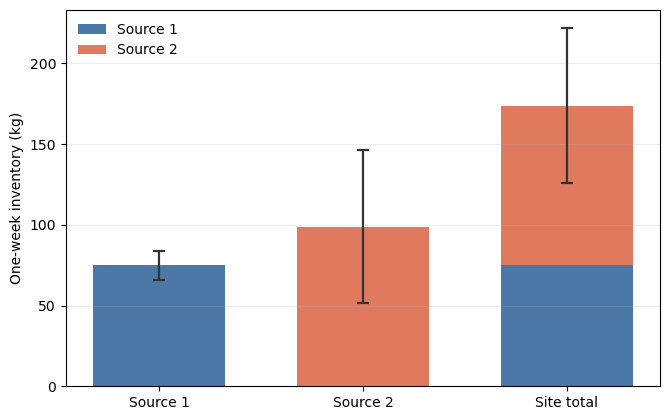

In [19]:
source_results = {}
rows = []
for source, frame in source_data.items():
    information = frame.loc[frame["is_information"]]
    result = source_inventory(
        information["rate_kg_per_hr"],
        information["variance_kg2_per_hr2"],
        N=N_INTERVALS,
        dt=DT_HOURS,
    )
    source_results[source] = result
    rows.append(
        {
            "inventory": source,
            "information_fraction": result["n_information"] / N_INTERVALS,
            "information_intervals": result["n_information"],
            "estimate_kg": result["estimate"],
            "standard_error_kg": result["standard_error"],
            "ci95_lower_kg": result["ci95"][0],
            "ci95_upper_kg": result["ci95"][1],
        }
    )

site_estimate = sum(result["estimate"] for result in source_results.values())
site_variance = sum(result["variance"] for result in source_results.values())
site_standard_error = np.sqrt(site_variance)
rows.append(
    {
        "inventory": "Site total",
        "information_fraction": pd.NA,
        "information_intervals": pd.NA,
        "estimate_kg": site_estimate,
        "standard_error_kg": site_standard_error,
        "ci95_lower_kg": max(0.0, site_estimate - 1.96 * site_standard_error),
        "ci95_upper_kg": site_estimate + 1.96 * site_standard_error,
    }
)

results = pd.DataFrame(rows).set_index("inventory")
display(results.round(3))
plot_inventory_estimates(results)


To explore information availability and skewness of the underlying source rate distributions, change the parameters at the top cell of the notebook. 